# HW 10 - Random walk

Name: TODO

Goal: Create computer simulations of natural phenomena

## Resources

- [Recorded lecture](https://csus.zoom.us/rec/share/oGjfwA-iSLBvooI_Wr55eGmpfhxOnISDwpztCfbgF0jTWI1-RN8dtGjF3Yeq70_G.8iY27pSI3qr2buz5)
- [Quick Start](https://numpy.org/doc/stable/reference/random/index.html) Numpy documentation on random number generation

## Q1

Here is a formal mathematical description of a two dimensional random walk:

If the position at time $t$ is $(x, y)$, then the position at time $t + 1$ will be one of:

$$
\{ (x+1, y), \: (x, y+1), \: (x-1, y), \: (x, y-1) \}
$$

Each of these events occurs with equal probability $p = \frac{1}{4}$.

_Describe informally in your own words what a two dimensional random walk with $n$ steps means._

A two-dimensional random walk with $n$ steps means you start at a random point on a grid, then for each step (tick, second, loop, etc) you randomly move ONE unit in any of the four directions (up, down, left, right). Each direction has an equal chance of occuring (25%) but is selected randomly during each step, until we've taken $n$ total steps.

## Q2

Define a function `random_walk(n)` that returns a tuple containing the x and y coordinates of a two dimensional random walk with $n$ steps.

In [3]:
import random

def random_walk(n):
    x = [0]
    y = [0]

    for s in range(n):
        step = random.choice(['up', 'down', 'left', 'right'])
        
        if step == 'up':
            x.append(x[-1])
            y.append(y[-1] + 1)
        elif step == 'down':
            x.append(x[-1])
            y.append(y[-1] - 1)
        elif step == 'left':
            x.append(x[-1] - 1)
            y.append(y[-1])
        else:
            x.append(x[-1] + 1)
            y.append(y[-1])
    
    return x, y

## Q3

Verify that your function works by running the following code, which should produce three random walks with different colors.

```py
for i in range(3):
    x, y = random_walk(1000)  # 1000 steps
    plt.plot(x, y)
    
plt.axis('equal')
```

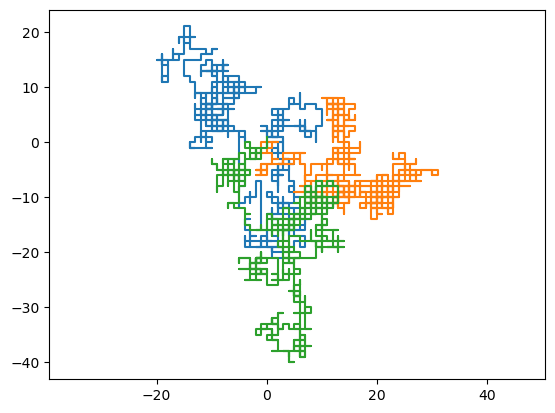

In [4]:
import matplotlib.pyplot as plt

for i in range(3):
    x, y = random_walk(1000)
    plt.plot(x, y)

plt.axis('equal')
plt.show()

## Q4

Use the `random_walk` function defined above to create a GIF animating the random walk similar to the [one on Wikipedia](https://upload.wikimedia.org/wikipedia/commons/f/f3/Random_walk_2500_animated.svg). Use `plt.title()` to include your name in the title. Save the file as `random-walk.gif` and turn it in as well as the HTML from this notebook.

Hint: Follow the notes from class.

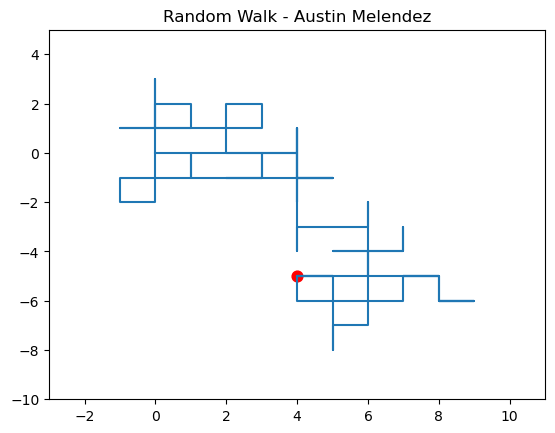

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

x, y = random_walk(100)

fig, ax = plt.subplots()

dot = ax.scatter(x[0], y[0], c="red", s=60)
line = ax.plot(x[0], y[0])[0]

# Make axes fixed
ax.set_xlim(min(x)-2, max(x)+2)
ax.set_ylim(min(y)-2, max(y)+2)
ax.set_title("Random Walk - Austin Melendez")

def update(frame):
    # Update trail line
    line.set_xdata(x[:frame])
    line.set_ydata(y[:frame])
    
    # Update moving point
    dot.set_offsets([x[frame-1], y[frame-1]])
    
    return dot, line

# Create animation
ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x),
    interval=20,
    blit=True
)

HTML(ani.to_jshtml())

In [6]:
writer = animation.PillowWriter(fps=30, metadata=dict(artist="Austin Melendez"))
ani.save("random-walk.gif", writer=writer)